In [1]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib

In [2]:
df = pd.read_csv("/content/Training.csv")

In [3]:
if "Unnamed: 133" in df.columns:
    df.drop("Unnamed: 133", axis=1, inplace=True)

In [4]:
df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [5]:
print("Dataset Shape")

print("-----------------------")

print("Rows :",df.shape[0])

print("Columns :",df.shape[1])

Dataset Shape
-----------------------
Rows : 4920
Columns : 133


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB


In [7]:
print("Missing Values")

print("----------------")

print(df.isnull().sum().sum())

Missing Values
----------------
0


In [8]:
df.fillna(0, inplace=True)

In [9]:
print(df.isnull().sum().sum())

0


In [10]:
duplicates=df.duplicated().sum()

print("Duplicate Records :",duplicates)

Duplicate Records : 4616


In [11]:
df=df.drop_duplicates()

print("New Dataset Shape")

print(df.shape)

New Dataset Shape
(304, 133)


In [12]:
df.describe()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
count,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,...,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,0.134868,0.138158,0.013158,0.039474,0.013158,0.174342,0.151316,0.036184,0.049342,0.019737,...,0.013158,0.013158,0.013158,0.019737,0.019737,0.019737,0.019737,0.016447,0.016447,0.016447
std,0.342146,0.345635,0.114139,0.195040,0.114139,0.380029,0.358947,0.187056,0.216938,0.139324,...,0.114139,0.114139,0.114139,0.139324,0.139324,0.139324,0.139324,0.127398,0.127398,0.127398
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
print(df.columns.tolist())

['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain', 'weakness_in_limbs', 'fast_heart_rate', 'pain_during_bow

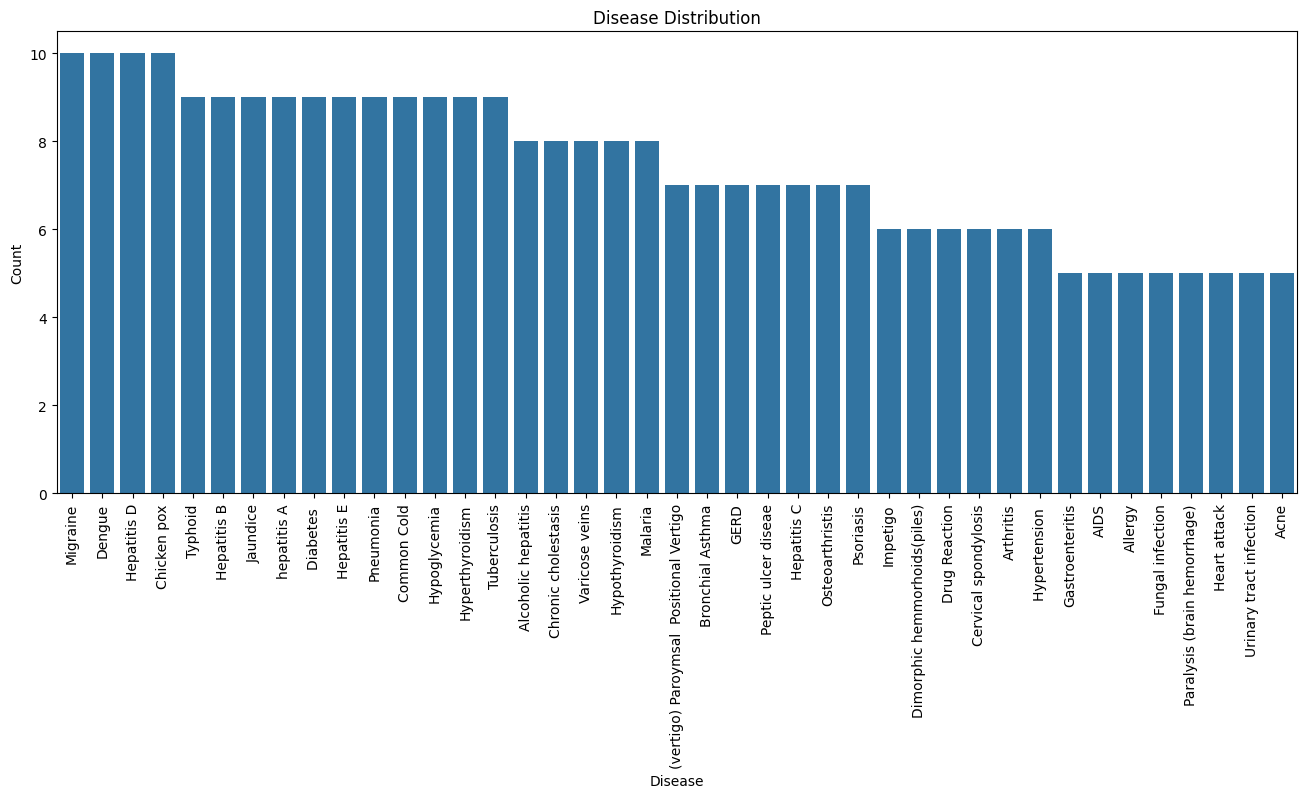

In [14]:
plt.figure(figsize=(16,6))

sns.countplot(
    data=df,
    x="prognosis",
    order=df["prognosis"].value_counts().index
)

plt.xticks(rotation=90)

plt.xlabel("Disease")

plt.ylabel("Count")

plt.title("Disease Distribution")

plt.show()

In [15]:
print("Number of Diseases")

print("----------------------")

print(df["prognosis"].nunique())

Number of Diseases
----------------------
41


In [16]:
df["prognosis"].value_counts().head(10)

,count
prognosis,
Migraine,10
Dengue,10
Hepatitis D,10
Chicken pox,10
Typhoid,9
Hepatitis B,9
Jaundice,9
hepatitis A,9
Diabetes,9


In [17]:
X=df.drop("prognosis",axis=1)

y=df["prognosis"]

print("Feature Matrix Shape :",X.shape)

print("Target Shape :",y.shape)

Feature Matrix Shape : (304, 132)
Target Shape : (304,)


In [18]:
encoder=LabelEncoder()

y=encoder.fit_transform(y)

print("Disease Labels Encoded Successfully")

Disease Labels Encoded Successfully


In [19]:
disease_mapping=dict(zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
))

print(disease_mapping)

{'(vertigo) Paroymsal  Positional Vertigo': np.int64(0), 'AIDS': np.int64(1), 'Acne': np.int64(2), 'Alcoholic hepatitis': np.int64(3), 'Allergy': np.int64(4), 'Arthritis': np.int64(5), 'Bronchial Asthma': np.int64(6), 'Cervical spondylosis': np.int64(7), 'Chicken pox': np.int64(8), 'Chronic cholestasis': np.int64(9), 'Common Cold': np.int64(10), 'Dengue': np.int64(11), 'Diabetes ': np.int64(12), 'Dimorphic hemmorhoids(piles)': np.int64(13), 'Drug Reaction': np.int64(14), 'Fungal infection': np.int64(15), 'GERD': np.int64(16), 'Gastroenteritis': np.int64(17), 'Heart attack': np.int64(18), 'Hepatitis B': np.int64(19), 'Hepatitis C': np.int64(20), 'Hepatitis D': np.int64(21), 'Hepatitis E': np.int64(22), 'Hypertension ': np.int64(23), 'Hyperthyroidism': np.int64(24), 'Hypoglycemia': np.int64(25), 'Hypothyroidism': np.int64(26), 'Impetigo': np.int64(27), 'Jaundice': np.int64(28), 'Malaria': np.int64(29), 'Migraine': np.int64(30), 'Osteoarthristis': np.int64(31), 'Paralysis (brain hemorrhag

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :",X_train.shape)

print("Validation Data :",X_val.shape)

Training Data : (243, 132)
Validation Data : (61, 132)


In [21]:
print(X_train.head())

     itching  skin_rash  nodal_skin_eruptions  continuous_sneezing  shivering  \
196        0          0                     0                    0          0   
396        0          1                     0                    0          0   
326        0          0                     0                    0          0   
173        0          1                     0                    0          0   
151        0          0                     0                    0          0   

     chills  joint_pain  stomach_pain  acidity  ulcers_on_tongue  ...  \
196       0           1             0        0                 0  ...   
396       0           1             0        0                 0  ...   
326       0           0             0        0                 0  ...   
173       1           1             0        0                 0  ...   
151       1           0             0        0                 0  ...   

     pus_filled_pimples  blackheads  scurring  skin_peeling  \
196        

In [22]:
print("Training Samples :",len(X_train))

print("Validation Samples :",len(X_val))

print("Number of Diseases :",len(encoder.classes_))

Training Samples : 243
Validation Samples : 61
Number of Diseases : 41


In [23]:
# Create Machine Learning Models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=500
    ),

    "Naive Bayes": GaussianNB(),

    "Support Vector Machine": SVC(
        kernel='linear',
        probability=True,
        random_state=42
    )
}

In [24]:
# Train Models
trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

In [25]:
# Prediction on Validation Dataset
predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_val)

    predictions[name] = y_pred

print("Prediction Completed")

Prediction Completed


In [26]:
# Accuracy Comparison

accuracy = {}

for name in trained_models:

    acc = accuracy_score(y_val, predictions[name])

    accuracy[name] = acc

    print(f"{name} Accuracy : {acc:.4f}")

Decision Tree Accuracy : 0.7049
Random Forest Accuracy : 1.0000
Logistic Regression Accuracy : 1.0000
Naive Bayes Accuracy : 0.9836
Support Vector Machine Accuracy : 1.0000


In [27]:
accuracy_df = pd.DataFrame(
    accuracy.items(),
    columns=["Model", "Accuracy"]
)

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_df.reset_index(drop=True, inplace=True)

accuracy_df

,Model,Accuracy
0,Random Forest,1.000000
1,Support Vector Machine,1.000000
2,Logistic Regression,1.000000
3,Naive Bayes,0.983607
4,Decision Tree,0.704918


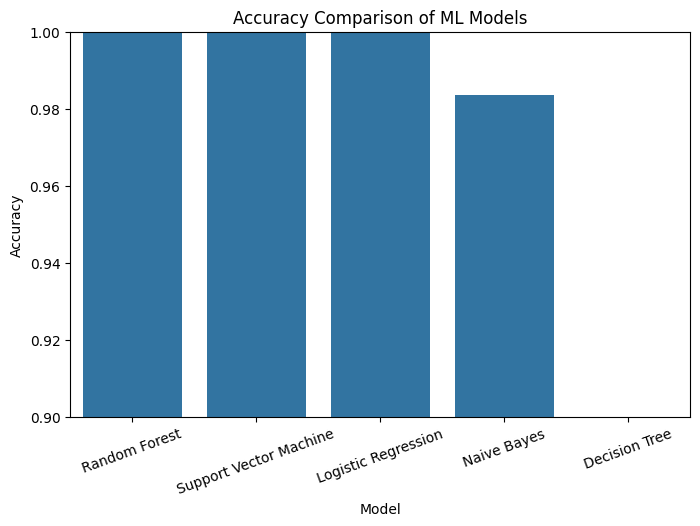

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of ML Models")

plt.xticks(rotation=20)

plt.ylim(0.9,1.0)

plt.show()

In [29]:
best_model_name = accuracy_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model :", best_model_name)

Best Model : Random Forest


In [30]:
joblib.dump(best_model, "best_disease_model.pkl")

joblib.dump(encoder, "label_encoder.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [31]:
loaded_model = joblib.load("best_disease_model.pkl")

loaded_encoder = joblib.load("label_encoder.pkl")

print("Saved Model Loaded Successfully")

Saved Model Loaded Successfully


In [32]:
print("Total Models Trained :", len(trained_models))

print("Best Model :", best_model_name)

print("Best Accuracy :", round(accuracy_df.iloc[0]["Accuracy"]*100,2), "%")

Total Models Trained : 5
Best Model : Random Forest
Best Accuracy : 100.0 %


In [33]:
# Load Testing Dataset

test_df = pd.read_csv("/content/Testing.csv")

test_df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,0,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Allergy
2,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,GERD
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Chronic cholestasis
4,1,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Drug Reaction


In [34]:
if "Unnamed: 133" in test_df.columns:
    test_df.drop("Unnamed: 133", axis=1, inplace=True)

In [35]:
print("Testing Dataset Shape")

print("-------------------------")

print("Rows :", test_df.shape[0])

print("Columns :", test_df.shape[1])

Testing Dataset Shape
-------------------------
Rows : 42
Columns : 133


In [36]:
print("Missing Values")

print("----------------")

print(test_df.isnull().sum().sum())

Missing Values
----------------
0


In [37]:
test_df.fillna(0, inplace=True)

In [38]:
X_test = test_df.drop("prognosis", axis=1)

y_test = test_df["prognosis"]

print("Testing Features :", X_test.shape)

print("Testing Labels :", y_test.shape)

Testing Features : (42, 132)
Testing Labels : (42,)


In [39]:
y_test = encoder.transform(y_test)

print("Testing Labels Encoded Successfully")

Testing Labels Encoded Successfully


In [40]:
y_pred = best_model.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [41]:
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy :", round(test_accuracy*100,2), "%")


Test Accuracy : 97.62 %


In [42]:
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
                           

In [43]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]]


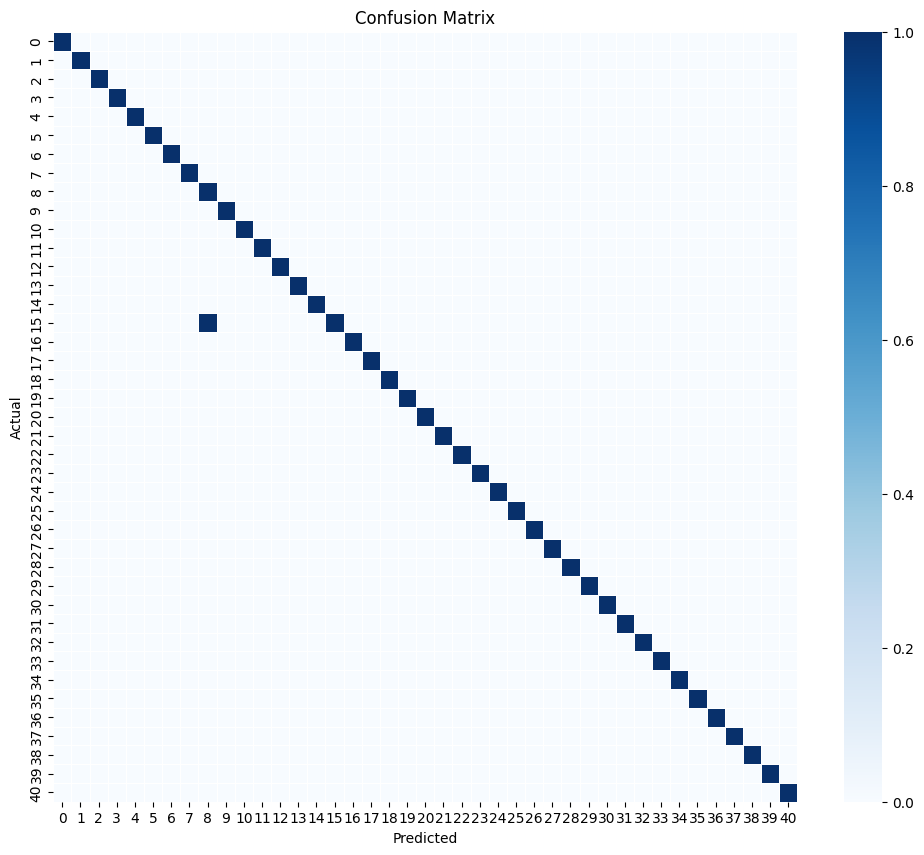

In [44]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [45]:
if best_model_name == "Random Forest":

    importance = pd.DataFrame({
        "Symptom": X.columns,
        "Importance": best_model.feature_importances_
    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(importance.head(10))

              Symptom  Importance
0             itching    0.021058
97        muscle_pain    0.020127
14            fatigue    0.019955
11           vomiting    0.019061
6          joint_pain    0.018299
43  yellowing_of_eyes    0.018039
5              chills    0.016751
25         high_fever    0.016438
41         mild_fever    0.016225
34             nausea    0.015695


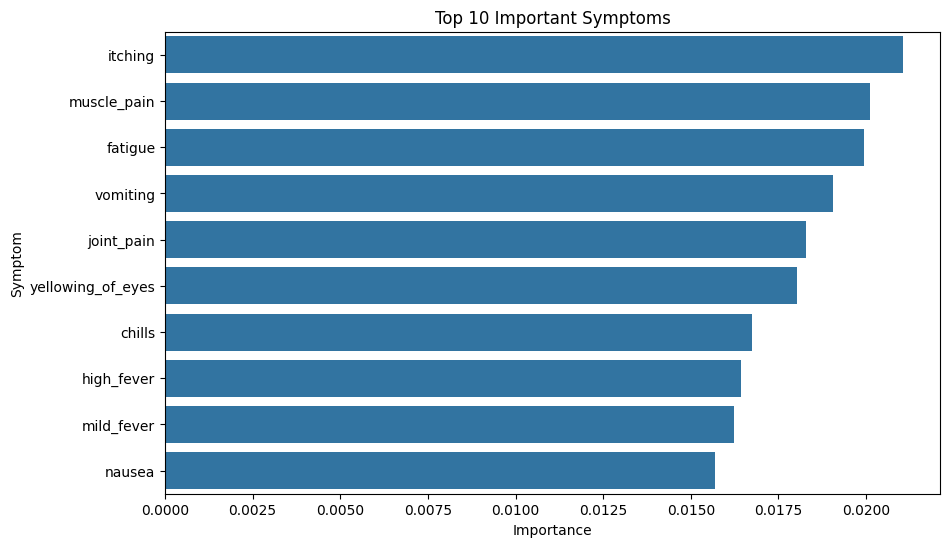

In [46]:
if best_model_name == "Random Forest":

    plt.figure(figsize=(10,6))

    top_features = importance.head(10)

    sns.barplot(
        data=top_features,
        x="Importance",
        y="Symptom"
    )

    plt.title("Top 10 Important Symptoms")

    plt.show()

In [47]:
sample_predictions = pd.DataFrame({
    "Actual Disease": encoder.inverse_transform(y_test[:10]),
    "Predicted Disease": encoder.inverse_transform(y_pred[:10])
})

sample_predictions

,Actual Disease,Predicted Disease
0,Fungal infection,Fungal infection
1,Allergy,Allergy
2,GERD,GERD
3,Chronic cholestasis,Chronic cholestasis
4,Drug Reaction,Drug Reaction
5,Peptic ulcer diseae,Peptic ulcer diseae
6,AIDS,AIDS
7,Diabetes,Diabetes
8,Gastroenteritis,Gastroenteritis
9,Bronchial Asthma,Bronchial Asthma


In [48]:
print("Best Model :", best_model_name)

print("Testing Accuracy :", round(test_accuracy*100,2), "%")

print("Number of Diseases :", len(encoder.classes_))

Best Model : Random Forest
Testing Accuracy : 97.62 %
Number of Diseases : 41


In [49]:
# Display Available Symptoms

symptoms = list(X.columns)

print("Total Symptoms :", len(symptoms))
print("\nAvailable Symptoms:\n")

for i, symptom in enumerate(symptoms, start=1):
    print(f"{i}. {symptom}")

Total Symptoms : 132

Available Symptoms:

1. itching
2. skin_rash
3. nodal_skin_eruptions
4. continuous_sneezing
5. shivering
6. chills
7. joint_pain
8. stomach_pain
9. acidity
10. ulcers_on_tongue
11. muscle_wasting
12. vomiting
13. burning_micturition
14. spotting_ urination
15. fatigue
16. weight_gain
17. anxiety
18. cold_hands_and_feets
19. mood_swings
20. weight_loss
21. restlessness
22. lethargy
23. patches_in_throat
24. irregular_sugar_level
25. cough
26. high_fever
27. sunken_eyes
28. breathlessness
29. sweating
30. dehydration
31. indigestion
32. headache
33. yellowish_skin
34. dark_urine
35. nausea
36. loss_of_appetite
37. pain_behind_the_eyes
38. back_pain
39. constipation
40. abdominal_pain
41. diarrhoea
42. mild_fever
43. yellow_urine
44. yellowing_of_eyes
45. acute_liver_failure
46. fluid_overload
47. swelling_of_stomach
48. swelled_lymph_nodes
49. malaise
50. blurred_and_distorted_vision
51. phlegm
52. throat_irritation
53. redness_of_eyes
54. sinus_pressure
55. runny_n

In [50]:
# Disease Prediction Function

def predict_disease(user_symptoms):

    input_data = np.zeros(len(X.columns))

    for symptom in user_symptoms:

        symptom = symptom.strip().lower()

        if symptom in X.columns:
            index = X.columns.get_loc(symptom)
            input_data[index] = 1
        else:
            print(f"Warning: '{symptom}' not found in dataset.")

    prediction = best_model.predict([input_data])[0]

    disease = encoder.inverse_transform([prediction])[0]

    return disease

In [51]:
# Prediction Confidence

def predict_with_confidence(user_symptoms):

    input_data = np.zeros(len(X.columns))

    for symptom in user_symptoms:

        symptom = symptom.strip().lower()

        if symptom in X.columns:
            input_data[X.columns.get_loc(symptom)] = 1

    prediction = best_model.predict([input_data])[0]

    disease = encoder.inverse_transform([prediction])[0]

    confidence = None

    if hasattr(best_model, "predict_proba"):

        probability = best_model.predict_proba([input_data])[0]

        confidence = max(probability) * 100

    return disease, confidence

In [52]:
sample = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]

disease, confidence = predict_with_confidence(sample)

print("Predicted Disease :", disease)

if confidence is not None:
    print("Confidence :", round(confidence,2), "%")

Predicted Disease : Fungal infection
Confidence : 79.0 %


In [53]:
# Disease Information

disease_info = {

    "Fungal infection":{
        "Description":"A fungal infection affecting the skin.",
        "Precautions":[
            "Keep skin clean",
            "Avoid sharing towels",
            "Use antifungal cream",
            "Consult a dermatologist"
        ]
    },

    "Common Cold":{
        "Description":"A viral infection affecting the nose and throat.",
        "Precautions":[
            "Drink warm fluids",
            "Take adequate rest",
            "Maintain good hygiene",
            "Consult a doctor if symptoms worsen"
        ]
    },

    "Malaria":{
        "Description":"A mosquito-borne infectious disease.",
        "Precautions":[
            "Take prescribed medication",
            "Drink plenty of water",
            "Use mosquito nets",
            "Visit a healthcare professional"
        ]
    },

    "Diabetes":{
        "Description":"A chronic condition affecting blood sugar regulation.",
        "Precautions":[
            "Exercise regularly",
            "Monitor blood sugar",
            "Follow a healthy diet",
            "Take medication as prescribed"
        ]
    }
}

In [54]:
def show_disease_info(disease):

    print("\nPredicted Disease :", disease)

    if disease in disease_info:

        print("\nDescription")

        print(disease_info[disease]["Description"])

        print("\nPrecautions")

        for item in disease_info[disease]["Precautions"]:
            print("✔", item)

    else:
        print("\nDisease Information Not Available")


In [55]:
# AI Healthcare Chatbot

def chatbot():

    print("="*60)
    print("AI Healthcare Diagnosis Assistant")
    print("="*60)

    print("\nEnter symptoms separated by commas.")
    print("Example:")
    print("itching, skin_rash, nodal_skin_eruptions")

    print("\nType 'exit' to quit.\n")

    while True:

        user = input("Your Symptoms : ")

        if user.lower() == "exit":
            print("\nThank you for using the Healthcare Assistant.")
            break

        symptoms = user.split(",")

        disease, confidence = predict_with_confidence(symptoms)

        print("\nPredicted Disease :", disease)

        if confidence is not None:
            print("Confidence :", round(confidence,2), "%")

        show_disease_info(disease)

        print("\n" + "-"*60)

In [56]:
# Disease Knowledge Base

health_data = {

    "Fungal infection": {
        "description": "A fungal infection affects the skin, nails or hair.",
        "diet": "Drink plenty of water and consume Vitamin C rich foods.",
        "precautions": [
            "Keep skin clean and dry",
            "Avoid sharing towels",
            "Use antifungal medication",
            "Consult a dermatologist"
        ]
    },

    "Common Cold": {
        "description": "A viral infection affecting the upper respiratory tract.",
        "diet": "Warm soup, fruits, fluids and light meals.",
        "precautions": [
            "Drink warm water",
            "Take proper rest",
            "Wash hands regularly",
            "Avoid cold drinks"
        ]
    },

    "Malaria": {
        "description": "Mosquito-borne infectious disease caused by parasites.",
        "diet": "Drink ORS, coconut water and eat nutritious food.",
        "precautions": [
            "Use mosquito nets",
            "Complete medication course",
            "Stay hydrated",
            "Consult doctor immediately"
        ]
    },

    "Diabetes": {
        "description": "A chronic disease affecting blood glucose levels.",
        "diet": "High fiber diet and low sugar intake.",
        "precautions": [
            "Exercise daily",
            "Monitor blood sugar",
            "Take medicines regularly",
            "Avoid sugary foods"
        ]
    }
}

In [57]:
def disease_details(disease):

    print("\n" + "="*60)
    print("HEALTH REPORT")
    print("="*60)

    print("Predicted Disease :", disease)

    if disease in health_data:

        print("\nDescription")
        print(health_data[disease]["description"])

        print("\nRecommended Diet")
        print(health_data[disease]["diet"])

        print("\nPrecautions")

        for p in health_data[disease]["precautions"]:
            print("✔", p)

    else:

        print("\nInformation not available.")

    print("\nDISCLAIMER")
    print("This prediction is generated by an AI model.")
    print("Always consult a qualified medical professional for diagnosis and treatment.")

In [58]:
def disease_details(disease):

    print("\n" + "="*60)
    print("HEALTH REPORT")
    print("="*60)

    print("Predicted Disease :", disease)

    if disease in health_data:

        print("\nDescription")
        print(health_data[disease]["description"])

        print("\nRecommended Diet")
        print(health_data[disease]["diet"])

        print("\nPrecautions")

        for p in health_data[disease]["precautions"]:
            print("✔", p)

    else:

        print("\nInformation not available.")

In [59]:
prediction_history = []

In [60]:
def save_prediction(symptoms, disease):

    prediction_history.append({
        "Symptoms": symptoms,
        "Disease": disease
    })

In [61]:
def show_history():

    if len(prediction_history) == 0:

        print("\nNo prediction history available.")

        return

    history = pd.DataFrame(prediction_history)

    print(history)

In [62]:
def health_chatbot():

    print("\nWelcome to AI Healthcare Chatbot")
    print("Ask a health question or type 'back' to return.")

    while True:

        question = input("\nQuestion : ").lower()

        if question == "back":
            break

        elif "fever" in question:
            print("\nFever is usually caused by infection. Stay hydrated and monitor your temperature.")

        elif "diabetes" in question:
            print("\nDiabetes is a chronic condition where the body cannot regulate blood sugar properly.")

        elif "malaria" in question:
            print("\nMalaria spreads through infected mosquito bites. Seek medical care promptly if suspected.")

        elif "covid" in question:
            print("\nCOVID-19 is a viral respiratory illness. Follow current public health guidance and consult a healthcare provider if symptoms are severe.")

        elif "headache" in question:
            print("\nHeadaches may have many causes such as stress, dehydration, or illness. Persistent or severe headaches should be evaluated by a doctor.")

        elif "diet" in question:
            print("\nA balanced diet should include fruits, vegetables, whole grains, lean protein and adequate water.")

        else:
            print("\nSorry, I don't have information on that topic.")

In [63]:
def healthcare_assistant():

    while True:

        print("\n" + "="*60)
        print("AI POWERED HEALTHCARE DIAGNOSIS ASSISTANT")
        print("="*60)

        print("1. Predict Disease")
        print("2. Healthcare Chatbot")
        print("3. View Prediction History")
        print("4. Exit")

        choice = input("\nEnter Choice : ")

        if choice == "1":

            symptom_input = input(
                "\nEnter symptoms separated by commas:\n"
            )

            symptoms = [
                s.strip().lower()
                for s in symptom_input.split(",")
            ]

            disease, confidence = predict_with_confidence(symptoms)

            print("\nPrediction Completed")

            print("\nPredicted Disease :", disease)

            if confidence is not None:
                print("Confidence :", round(confidence,2), "%")

            disease_details(disease)

            save_prediction(symptom_input, disease)

        elif choice == "2":

            health_chatbot()

        elif choice == "3":

            show_history()

        elif choice == "4":

            print("\nThank you for using AI Healthcare Diagnosis Assistant.")

            break

        else:

            print("\nInvalid Choice.")

In [64]:
healthcare_assistant()


AI POWERED HEALTHCARE DIAGNOSIS ASSISTANT
1. Predict Disease
2. Healthcare Chatbot
3. View Prediction History
4. Exit

Enter Choice : 4

Thank you for using AI Healthcare Diagnosis Assistant.
